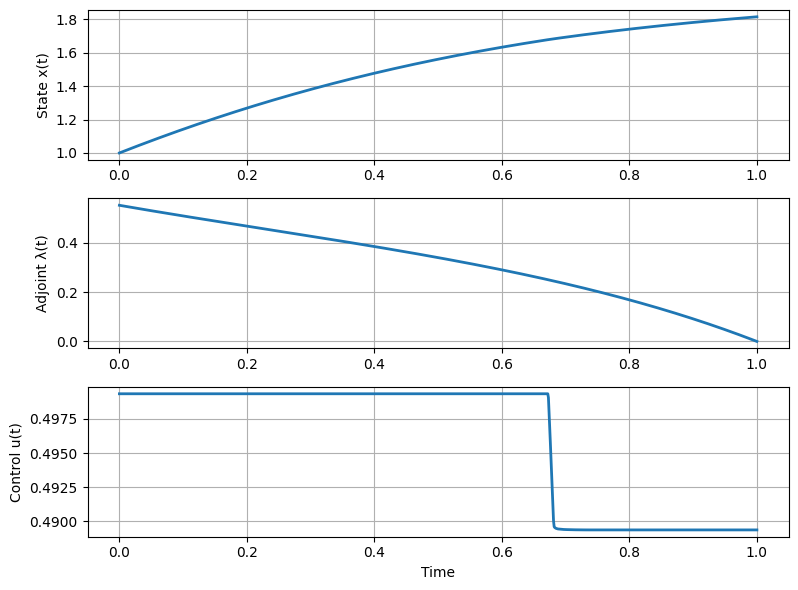

In [9]:
import numpy as np
import matplotlib.pyplot as plt

A = 1
C = 4
x0 = 1

M1 = 0.49
M2 = 0.5

delta = 0.001
N = 1000

t = np.linspace(0, 1, N + 1)
h = 1 / N

u_k = np.zeros(N + 1)
x_k = np.zeros(N + 1)
lambda_k = np.zeros(N + 1)

x_k[0] = x0
lambda_k[-1] = 0

converged = -1

while converged < 0:

    u_old = u_k.copy()
    x_old = x_k.copy()
    lambda_old = lambda_k.copy()

    for i in range(N):

        k1 = -0.5 * x_k[i]**2 + C * u_k[i]

        x_mid1 = x_k[i] + 0.5 * h * k1
        u_mid = 0.5 * (u_k[i] + u_k[i+1])

        k2 = -0.5 * x_mid1**2 + C * u_mid

        x_mid2 = x_k[i] + 0.5 * h * k2

        k3 = -0.5 * x_mid2**2 + C * u_mid

        x_end = x_k[i] + h * k3

        k4 = -0.5 * x_end**2 + C * u_k[i+1]

        x_k[i+1] = x_k[i] + (h / 6) * (k1 + 2*k2 + 2*k3 + k4)

    lambda_k[N] = 0


    for i in range(N):

        j = N - i

        k1 = -A + lambda_k[j] * x_k[j]

        lam_mid1 = lambda_k[j] - 0.5 * h * k1
        x_mid = 0.5 * (x_k[j] + x_k[j-1])

        k2 = -A + lam_mid1 * x_mid

        lam_mid2 = lambda_k[j] - 0.5 * h * k2

        k3 = -A + lam_mid2 * x_mid

        lam_end = lambda_k[j] - h * k3

        k4 = -A + lam_end * x_k[j-1]

        lambda_k[j-1] = lambda_k[j] \
                        - (h / 6) * (k1 + 2*k2 + 2*k3 + k4)


    u_new = 0.5 * C * lambda_k

    u_new = np.minimum(M2, np.maximum(M1, u_new))

    u_k = 0.4 * u_new + 0.6 * u_old

    tol_u = delta * np.sum(np.abs(u_k)) \
            - np.sum(np.abs(u_k - u_old))

    tol_x = delta * np.sum(np.abs(x_k)) \
            - np.sum(np.abs(x_k - x_old))

    tol_lambda = delta * np.sum(np.abs(lambda_k)) \
                 - np.sum(np.abs(lambda_k - lambda_old))

    converged = min(tol_u, tol_x, tol_lambda)

plt.figure(figsize=(8, 6))

plt.subplot(3, 1, 1)
plt.plot(t, x_k, linewidth=2)
plt.ylabel('State x(t)')
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(t, lambda_k, linewidth=2)
plt.ylabel('Adjoint λ(t)')
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(t, u_k, linewidth=2)
plt.ylabel('Control u(t)')
plt.xlabel('Time')
plt.grid()

plt.tight_layout()
plt.show()